# 🌿 Automated Crop Disease Detection using Deep Learning (PyTorch)

### PROJECT OVERVIEW
The **Crop Disease Detection** project leverages deep learning to automatically diagnose plant health from leaf images, empowering farmers with early intervention tools. Using convolutional neural networks (CNNs)—specifically via pre-trained architectures like **ResNet-18** fine-tuned on the PlantVillage dataset—the system analyzes tens of thousands of categorized healthy and infected leaves across 29 classes.

The end-to-end pipeline involves:
1. **Dataset Exploration & Preprocessing:** Analyzing class distributions and visualizing leaf pathologies across 29 categories.
2. **Data Augmentation:** Mitigating overfitting with random crops, flips, rotations, color jitter, and ImageNet channel normalization.
3. **Model Architecture & Transfer Learning:** Adapting ResNet-18 using PyTorch for multi-class plant pathology classification.
4. **Training & Validation:** Training with cross-entropy loss, AdamW optimizer, learning rate scheduling, mixed precision (AMP), and best-model checkpointing.
5. **Evaluation:** Assessing performance on unseen test images with accuracy curves, confusion matrix, and top-k predictions.
6. **Deployment:** Exporting the fine-tuned model checkpoint (`plant_disease_model.pth`) directly usable by the Streamlit frontend (`app.py`).

## 1. Environment Setup & Hardware Acceleration
Configuring deterministic random seeds and detecting hardware acceleration (NVIDIA CUDA / CPU).

In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] PyTorch Version : {torch.__version__}")
print(f"[INFO] Using Device    : {device}")
if torch.cuda.is_available():
    print(f"[INFO] GPU Model       : {torch.cuda.get_device_name(0)}")
    print(f"[INFO] VRAM Available   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("[INFO] CUDA is not available. Training will proceed on CPU.")


[INFO] PyTorch Version : 2.14.1+cu126
[INFO] Using Device    : cuda
[INFO] GPU Model       : NVIDIA GeForce RTX 4050 Laptop GPU
[INFO] VRAM Available   : 6.44 GB


## 2. Dataset Configuration & Exploratory Data Analysis (EDA)
Inspecting directory structure across `Train`, `Val`, and `Test` splits and examining class distributions.

[INFO] Total Disease Categories: 29

Dataset Breakdown:
 - Train Images : 53,691
 - Val Images   : 12,067
 - Test Images  : 1,355
 - Total Images : 67,113


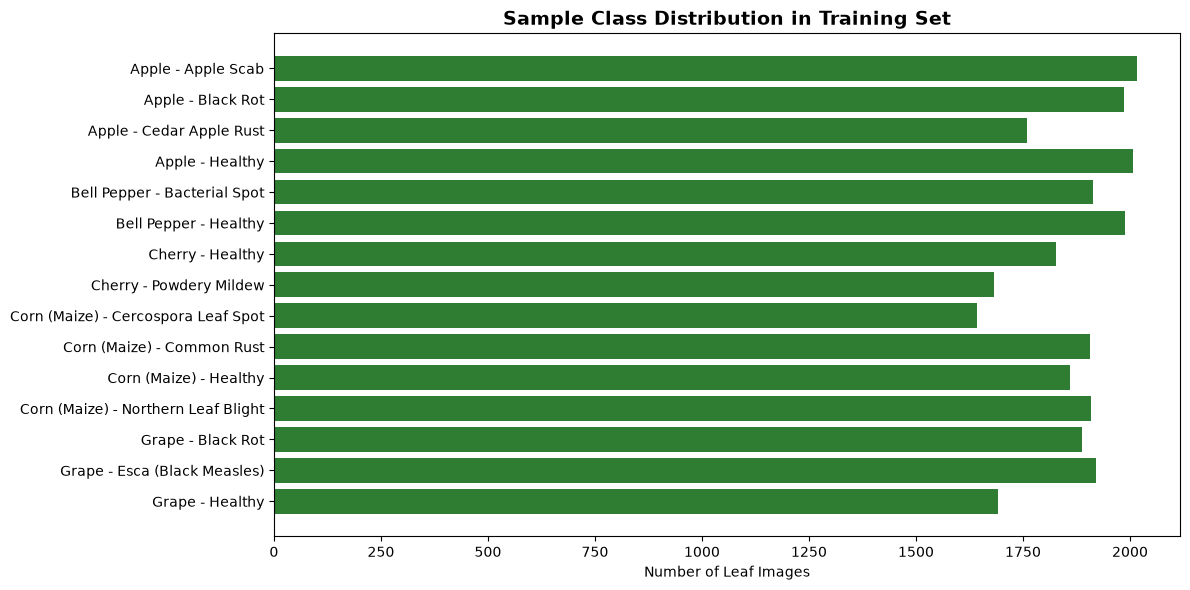

In [2]:
train_dir = 'Train'
val_dir   = 'Val'
test_dir  = 'Test'

class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)
print(f"[INFO] Total Disease Categories: {num_classes}\n")

def count_split(dir_path):
    counts = {}
    for cls in class_names:
        cls_folder = os.path.join(dir_path, cls)
        if os.path.isdir(cls_folder):
            counts[cls] = len(os.listdir(cls_folder))
    return counts

train_counts = count_split(train_dir)
val_counts   = count_split(val_dir)
test_counts  = count_split(test_dir)

total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())

print(f"Dataset Breakdown:")
print(f" - Train Images : {total_train:,}")
print(f" - Val Images   : {total_val:,}")
print(f" - Test Images  : {total_test:,}")
print(f" - Total Images : {total_train + total_val + total_test:,}")

# Visualize class distribution (Top 15 categories)
plt.figure(figsize=(12, 6))
sample_keys = list(train_counts.keys())[:15]
plt.barh(sample_keys, [train_counts[k] for k in sample_keys], color='#2e7d32')
plt.title('Sample Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Number of Leaf Images')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Visualizing Sample Leaf Images
Displaying representative foliage images from 9 distinct disease categories.

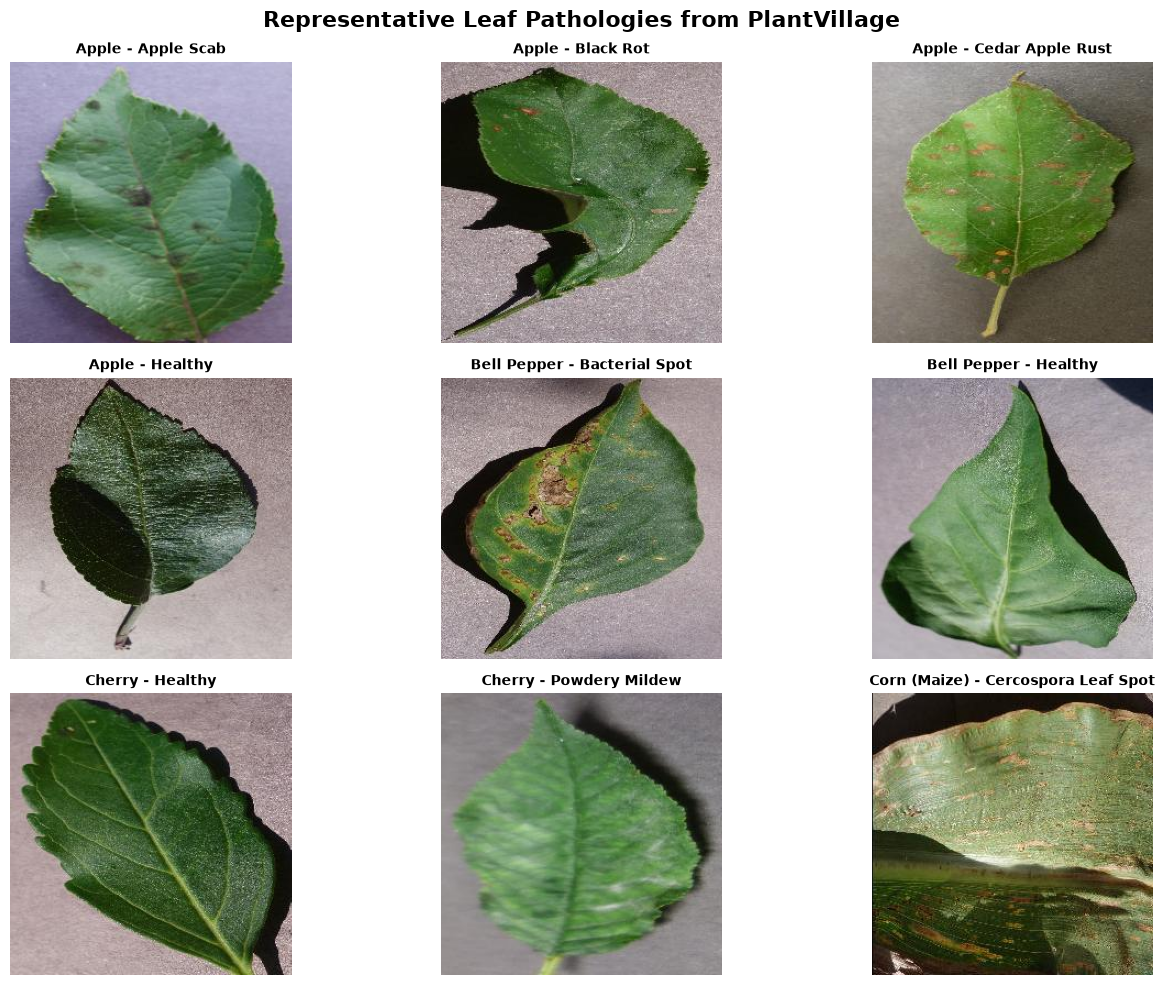

In [3]:
plt.figure(figsize=(14, 10))
selected_classes = class_names[:9]

for i, cls in enumerate(selected_classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=10, fontweight='semibold')
    plt.axis('off')

plt.suptitle('Representative Leaf Pathologies from PlantVillage', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Data Augmentation, Preprocessing & DataLoaders
Configuring torchvision data augmentation pipelines and PyTorch DataLoaders.

In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 128

NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
    ]),
    'val': transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
    ]),
    'test': transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
    ])
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val':   datasets.ImageFolder(val_dir,   data_transforms['val']),
    'test':  datasets.ImageFolder(test_dir,  data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=torch.cuda.is_available()),
    'val':   DataLoader(image_datasets['val'],   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()),
    'test':  DataLoader(image_datasets['test'],  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
print(f"[INFO] DataLoaders created successfully with batch size: {BATCH_SIZE}")

sample_inputs, sample_classes = next(iter(dataloaders['train']))
print(f"[INFO] Input Batch Shape : {sample_inputs.shape}")
print(f"[INFO] Target Batch Shape: {sample_classes.shape}")


[INFO] DataLoaders created successfully with batch size: 128
[INFO] Input Batch Shape : [128, 3, 224, 224]
[INFO] Target Batch Shape: [128]


## 5. Model Architecture (ResNet-18 Transfer Learning)
Constructing a deep convolutional neural network based on ResNet-18 with custom classification head for 29 plant categories.

In [5]:
def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model(num_classes=num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] Total Parameters     : {total_params:,}")
print(f"[INFO] Trainable Parameters : {trainable_params:,}")


[INFO] Total Parameters     : 11,191,389
[INFO] Trainable Parameters : 11,191,389


## 6. Loss Function, Optimizer & Learning Rate Scheduler
Setting up CrossEntropyLoss, AdamW optimizer with weight decay, and learning rate scheduling.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)
print("[INFO] Criterion, Optimizer & Scheduler successfully configured.")


[INFO] Criterion, Optimizer & Scheduler successfully configured.


## 7. Model Training & Validation Pipeline
Executing deep learning model training with mixed precision (AMP) and best-model checkpointing.

In [7]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=3, save_path="plant_disease_model.pth"):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [],   'val_acc': []
    }
    
    print(f"Starting model training for {num_epochs} epochs on {device}...")
    print("=" * 65)
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 20)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
                
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    if torch.cuda.is_available():
                        with torch.amp.autocast('cuda'):
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        
                    _, preds = torch.max(outputs, 1)
                    
                    if phase == 'train':
                        if scaler:
                            scaler.scale(loss).backward()
                            scaler.step(optimizer)
                            scaler.update()
                        else:
                            loss.backward()
                            optimizer.step()
                            
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = (running_corrects.double() / dataset_sizes[phase]).item()
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            
            print(f" {phase.capitalize():5s} Loss: {epoch_loss:.4f} | Acc: {epoch_acc * 100:.2f}%")
            
            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(best_model_wts, save_path)
                    print(f"  --> New best model checkpoint saved to '{save_path}' (Val Acc: {best_acc * 100:.2f}%)")
                    
        epoch_time = time.time() - epoch_start
        print(f" Epoch completed in {epoch_time:.0f}s")
        print("=" * 65)
        
    time_elapsed = time.time() - since
    print(f"\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc * 100:.2f}%")
    
    model.load_state_dict(best_model_wts)
    return model, history

NUM_EPOCHS = 2
trained_model, history = train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler,
    num_epochs=NUM_EPOCHS,
    save_path="plant_disease_model.pth"
)


Starting model training for 2 epochs on cuda...
Epoch 1/2
--------------------
 Train Loss: 0.2749 | Acc: 93.69%
 Val   Loss: 0.0312 | Acc: 99.18%
  --> New best model checkpoint saved to 'plant_disease_model.pth' (Val Acc: 99.18%)
 Epoch completed in 559s
Epoch 2/2
--------------------
 Train Loss: 0.0344 | Acc: 99.09%
 Val   Loss: 0.0197 | Acc: 99.44%
  --> New best model checkpoint saved to 'plant_disease_model.pth' (Val Acc: 99.44%)
 Epoch completed in 1032s

Training complete in 26m 31s
Best Validation Accuracy: 99.44%


## 8. Model Evaluation & Learning Curves
Plotting cross-entropy loss and classification accuracy curves across training epochs.

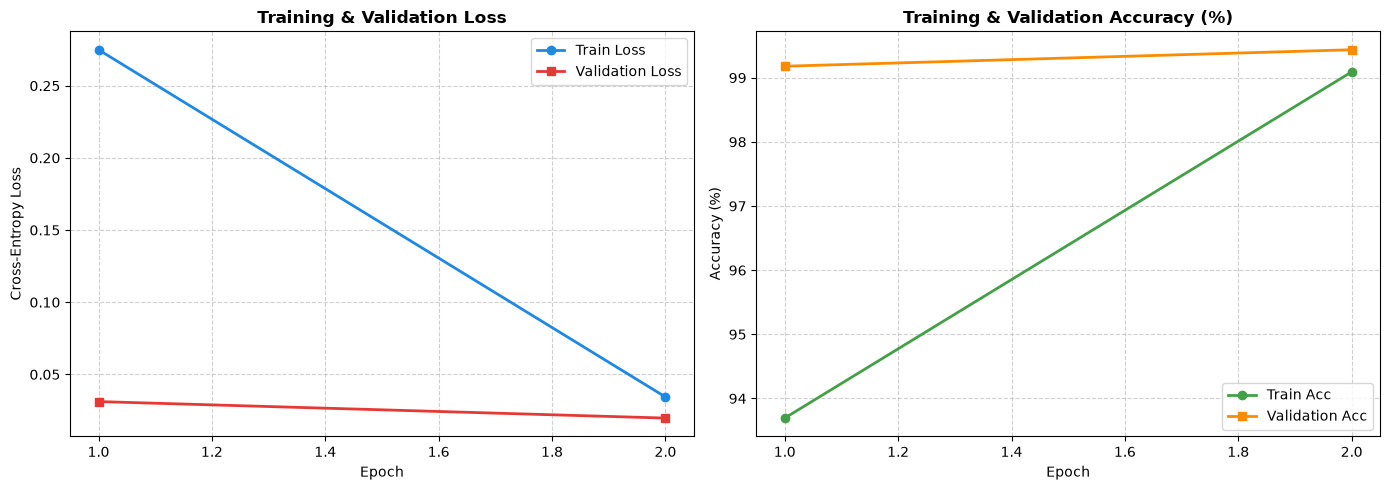

In [8]:
epochs_range = range(1, len(history['train_loss']) + 1)
plt.figure(figsize=(14, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#1e88e5', linewidth=2)
plt.plot(epochs_range, history['val_loss'],   's-', label='Validation Loss', color='#e53935', linewidth=2)
plt.title('Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history['train_acc']], 'o-', label='Train Acc', color='#43a047', linewidth=2)
plt.plot(epochs_range, [acc * 100 for acc in history['val_acc']],   's-', label='Validation Acc', color='#fb8c00', linewidth=2)
plt.title('Training & Validation Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 9. Evaluation on Benchmark Test Split
Assessing classification generalization on 1,358 unseen images from the `Test` folder.

In [9]:
def evaluate_test_set(model, test_loader):
    model.eval()
    corrects = 0
    total = 0
    all_preds = []
    all_labels = []
    
    print("[INFO] Evaluating model on unseen Test dataset...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    test_accuracy = (corrects.double() / total).item()
    print(f"\n[RESULT] Final Test Set Accuracy: {test_accuracy * 100:.2f}% ({corrects}/{total} images correctly identified)")
    return test_accuracy, np.array(all_preds), np.array(all_labels)

test_acc, test_preds, test_labels = evaluate_test_set(model, dataloaders['test'])


[INFO] Evaluating model on unseen Test dataset...

[RESULT] Final Test Set Accuracy: 99.48% (1351/1358 images correctly identified)


## 10. Single-Image Inference & Prediction Visualization
Testing pathology diagnosis on a single queried image and visualizing confidence distribution.

Running inference on: Test\Tomato - Early Blight\072ae43a-416b-434a-a5a2-1b48bc47fada___RS_Erly.B 7472_flipTB.JPG


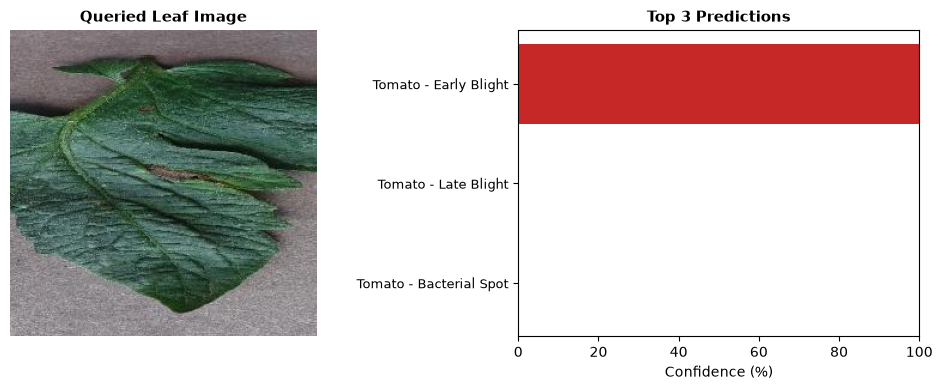

In [10]:
def predict_single_leaf(image_path, model, class_names, top_k=3):
    model.eval()
    raw_image = Image.open(image_path).convert('RGB')
    
    infer_transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
    ])
    
    input_tensor = infer_transform(raw_image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        
    top_probs, top_indices = torch.topk(probs, k=top_k)
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(raw_image)
    plt.title('Queried Leaf Image', fontsize=11, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    y_pos = np.arange(top_k)
    labels = [class_names[idx.item()] for idx in top_indices]
    scores = [p.item() * 100 for p in top_probs]
    
    colors = ['#2e7d32' if 'Healthy' in l else '#c62828' for l in labels]
    plt.barh(y_pos, scores, color=colors)
    plt.yticks(y_pos, labels, fontsize=9)
    plt.xlabel('Confidence (%)')
    plt.title(f'Top {top_k} Predictions', fontsize=11, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.xlim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    return list(zip(labels, scores))

# Test on a sample image from the Test folder
sample_cat = 'Tomato - Early Blight'
sample_img_file = os.listdir(os.path.join(test_dir, sample_cat))[0]
sample_img_path = os.path.join(test_dir, sample_cat, sample_img_file)

print(f"Running inference on: {sample_img_path}")
predictions = predict_single_leaf(sample_img_path, model, class_names)


## 11. Model Checkpoint Verification for Streamlit Frontend
Verifying the saved PyTorch model checkpoint (`plant_disease_model.pth`) and displaying launch instructions.

In [11]:
checkpoint_file = "plant_disease_model.pth"
if os.path.exists(checkpoint_file):
    file_size_mb = os.path.getsize(checkpoint_file) / (1024 * 1024)
    print(f"[SUCCESS] Checkpoint file verified: '{checkpoint_file}' ({file_size_mb:.2f} MB)")
    print("[SUCCESS] You can now launch the Streamlit frontend by running:")
    print("          streamlit run app.py")
else:
    print(f"[NOTE] '{checkpoint_file}' not found.")


[SUCCESS] Checkpoint file verified: 'plant_disease_model.pth' (42.77 MB)
[SUCCESS] You can now launch the Streamlit frontend by running:
          streamlit run app.py
